# 노트북 18 — LWE primal 공격

보상의 순간입니다. 장난감 LWE instance를 잡아 Kannan-embedding 격자를 만들고, BKZ로 축소해서 비밀이 튀어나오는 모습을 지켜봅니다.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
from pqc_edu.lwe import toy_keygen
from pqc_edu.attacks_advanced.primal import primal_attack

## Kannan embedding, 비공식적으로

LWE 샘플 $A \cdot s + e \equiv b \pmod q$가 주어졌을 때, 벡터 $(e, -s, 1)$을 (스케일을 제외하고) 포함하는 격자를 만듭니다. $e, s$가 작으므로 이 벡터도 짧습니다. BKZ가 충분히 짧은 기저를 찾는다면 $s$를 바로 읽어낼 수 있습니다.

기저 배치 (행 기반, 차원 $m + n + 1$):

- $n$개의 행 $(A[:,j], e_j, 0)$
- $m$개의 행 $(q \cdot e_i, 0, 0)$
- 1개의 행 $(b, 0, M)$

왜 이것이 동작하는가: 모든 격자 점의 마지막 좌표는 어떤 정수 $t$에 대해 $M \cdot t$입니다. $t = 1$로 놓고 $b$가 $As$와 상쇄되도록 계수를 고르면, 앞쪽 $m$개 좌표에 남는 잔차가 $e$가 됩니다.

**중요**: 이 공격은 $s$가 **작을** 때만 동작합니다. 우리는 `toy_keygen`에서 `small_secret=True`를 사용하며, 이는 $s$를 centered binomial 분포에서 샘플링합니다.

## 작은 공격: $n = 10$

In [2]:
rng = np.random.default_rng(0)
pk, sk = toy_keygen(n=10, q=97, sigma=0.8, rng=rng, m=20, small_secret=True)
print('secret:', sk.s)
result = primal_attack(pk, block_size=4, time_budget_s=60)
print(f'\nstatus: {result.status}')
print(f'reduction_time: {result.reduction_time:.1f}s')
if result.status == 'success':
    print(f'recovered s: {result.secret}')
    print(f'matches: {np.array_equal(result.secret % pk.q, sk.s % pk.q)}')

secret: [ 1  0 96 96 96  1  1  1  2  2]



status: success
reduction_time: 9.5s
recovered s: [ 1  0 96 96 96  1  1  1  2  2]
matches: True


## 차원에 따른 성공률

각 차원 $n$에 대해 독립적인 LWE instance를 소수 회 공격하고, 시간 예산 안에서 primal이 얼마나 자주 성공하는지 셉니다. 공격 비용은 $n$에 따라 급격히 커집니다 — BKZ-$\beta = 4$는 $n \approx 15$ 무렵 힘을 다하며, $\beta$를 키우면 벽을 더 밀어낼 수 있지만 지수적으로 더 많은 시간이 듭니다.

n= 8  success=2/2  avg time=  3.1s


n=10  success=2/2  avg time= 10.4s


n=12  success=2/2  avg time= 28.2s


n=14  success=2/2  avg time= 64.2s


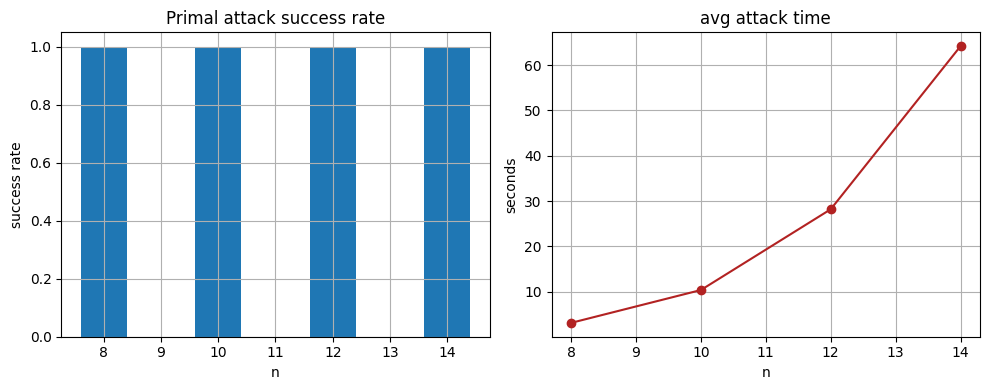

In [3]:
dims = [8, 10, 12, 14]
trials_per_dim = 2
success_rate = []
avg_time = []
for n in dims:
    successes = 0
    total_time = 0.0
    for trial in range(trials_per_dim):
        rng = np.random.default_rng(100 * n + trial)
        pk, _ = toy_keygen(n=n, q=max(31, 2 * n * n), sigma=0.8, rng=rng, m=2 * n, small_secret=True)
        t0 = time.time()
        result = primal_attack(pk, block_size=4, time_budget_s=90)
        total_time += time.time() - t0
        if result.status == 'success':
            successes += 1
    success_rate.append(successes / trials_per_dim)
    avg_time.append(total_time / trials_per_dim)
    print(f'n={n:2d}  success={successes}/{trials_per_dim}  avg time={avg_time[-1]:5.1f}s')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(dims, success_rate); axes[0].set_xlabel('n'); axes[0].set_ylabel('success rate'); axes[0].set_ylim(0, 1.05); axes[0].set_title('Primal attack success rate')
axes[1].plot(dims, avg_time, 'o-', color='firebrick'); axes[1].set_xlabel('n'); axes[1].set_ylabel('seconds'); axes[1].set_title('avg attack time')
for ax in axes: ax.grid(True)
plt.tight_layout(); plt.show()

## 패턴

- 작은 $n$ ($\le 15$)은 BKZ-4에 안정적으로 무너집니다.
- 더 큰 $n$은 더 큰 $\beta$가 필요합니다 — enumeration 비용이 $2^{O(\beta)}$ 정도이므로, 우리 순수 Python 버전은 벽에 부딪힙니다.
- ML-KEM은 유효 격자 차원 약 $n \cdot k + m \cdot k \approx 512$–$1024$에서 동작합니다. 이를 공격하려면 $\beta \approx 400+$가 필요합니다. 여기서 $2^{140}$ 비용 추정이 나옵니다 — 할 수 없는 일입니다.

→ 마지막 장: `19_ml_kem_parameters_and_estimator.ipynb`